In [10]:
import pywswat
import mikeio
import numpy as np

<Axes: title={'center': '1990-01-01 12:35:00'}, xlabel='Easting [m]', ylabel='Northing [m]'>

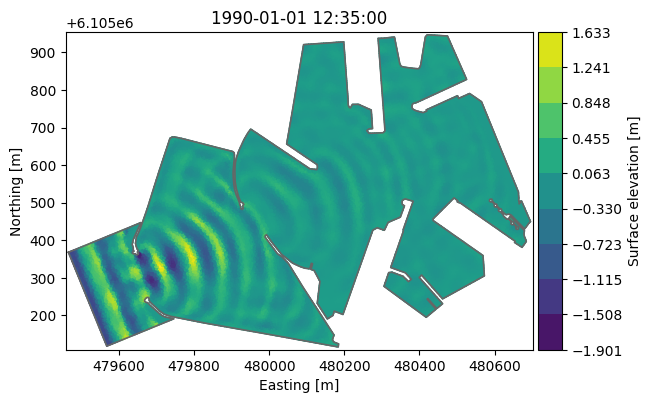

In [7]:
fn_sample = r"D:\STKI\M21WFM\Examples\Ronne\Tri_irregular_3d_refined.mwfm - Result Files\area.dfsu"
ds_u = mikeio.read(fn_sample)
ds_u["Surface elevation"].isel(time=-1).plot()

<Axes: title={'center': '1990-01-01 12:35:00'}, xlabel='Easting [m]', ylabel='Northing [m]'>

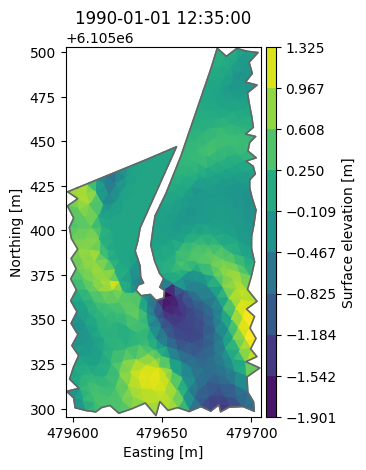

In [ ]:
xye = ds_u.geometry.element_coordinates
msk = np.where(
    (xye[:, 0] < 479680)
    & (xye[:, 0] > 479610)
    & (xye[:, 1] < 6105400)
    & (xye[:, 1] > 6105325)
)[0]
ds_u_sub = ds_u.isel(element=msk)
ds_u_sub["Surface elevation"].isel(time=-1).plot()

In [12]:
spec_u_sub = pywswat.spectrum_mem(
    ds_u_sub,
    "Surface elevation",
    u="Depth averaged U velocity",
    v="Depth averaged V velocity",
    method="newton",
    overlap=0.1,
    window_size=128,
)

Computing MEM spectrum at spatial locations: 100%|██████████| 882/882 [00:45<00:00, 19.31it/s]


In [17]:
ds = spec_u_sub.to_mikeio()

In [24]:
spec_u_sub._time

DatetimeIndex(['1990-01-01 12:17:30'], dtype='datetime64[s]', freq=None)

<Axes: title={'center': '1990-01-01 12:17:30'}, xlabel='Easting [m]', ylabel='Northing [m]'>

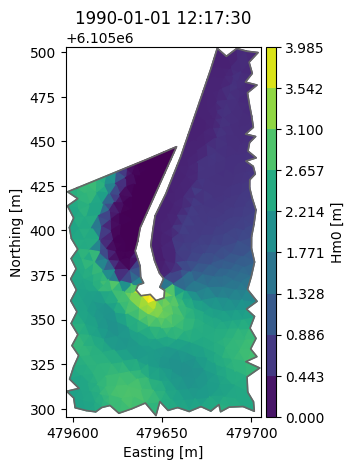

In [20]:
pywswat.io.to_params_dataset(spec_u_sub)["Hm0"].plot()